<a href="https://colab.research.google.com/github/vblancoOR/econometria/blob/master/01_ECO_estimacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1: Estimación e Inferencia en Modelos de Regresión Lineales

## Modelo 1

Carguemos una base de datos de Woldridge "csal1"

In [ ]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pylab as plt

#!pip install wooldridge

from wooldridge import *

dataWoo('ceosal1', description=True) #con description=True tenemos una descripción de las variables

name of dataset: ceosal1
no of variables: 12
no of observations: 209

+----------+-------------------------------+
| variable | label                         |
+----------+-------------------------------+
| salary   | 1990 salary, thousands $      |
| pcsalary | % change salary, 89-90        |
| sales    | 1990 firm sales, millions $   |
| roe      | return on equity, 88-90 avg   |
| pcroe    | % change roe, 88-90           |
| ros      | return on firm's stock, 88-90 |
| indus    | =1 if industrial firm         |
| finance  | =1 if financial firm          |
| consprod | =1 if consumer product firm   |
| utility  | =1 if transport. or utilties  |
| lsalary  | natural log of salary         |
| lsales   | natural log of sales          |
+----------+-------------------------------+

I took a random sample of data reported in the May 6, 1991 issue of
Businessweek.


Llamamos "datos" a los datos de esa base de datos, y dentro de tal, notamos por "y" al salario de los CEOS y a "X" la matriz de datos con columna de unos (constante) y "roe" (rendimiento medio del CEO):

In [ ]:
datos= dataWoo('ceosal1')

y=datos['salary']
X=sm.add_constant(datos[['roe', 'sales']])


## Estadísticos Descriptivos:

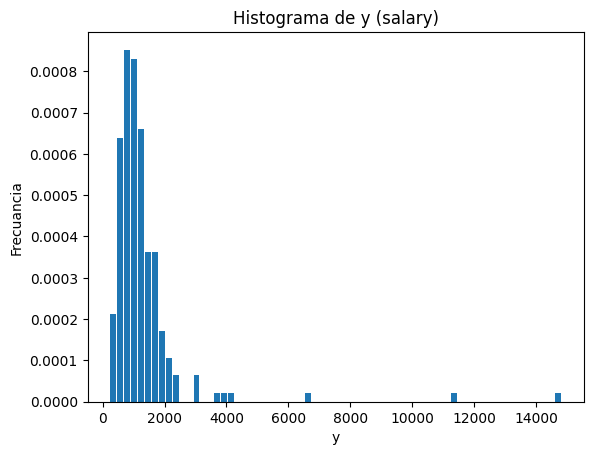

Q1:  736.0 Mediana: 1039.0 Q3:  1407.0 DT:  1369.0582486088983 Media: 1281.1196172248804


In [ ]:
media=np.mean(y)
Q1=np.quantile(y, 0.25)
Q3=np.quantile(y, 0.75)
Varianza=np.var(y)
DesviacionTipica=np.std(y)
Mediana=np.median(y)
histograma=plt.hist(y, bins='auto', rwidth=0.85, density=True)
plt.xlabel('y')
plt.ylabel('Frecuancia')
plt.title("Histograma de y (salary)")
plt.show()
print("Q1: ", Q1, "Mediana:",  Mediana, "Q3: ", Q3, "DT: ", DesviacionTipica, "Media:", np.mean(y))

Ahora ajustamos el modelo $y = X\beta + u$ y extraemos un resumen del resultado:

In [ ]:
mco1 = sm.OLS(y, X).fit()
mco1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.095
Date:                Tue, 24 Oct 2023   Prob (F-statistic):             0.0474
Time:                        06:46:02   Log-Likelihood:                -1802.8
No. Observations:                 209   AIC:                             3612.
Df Residuals:                     206   BIC:                             3622.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        830.6313    223.905      3.710      0.000     389.192    1272.070
roe           19.6310     11.077      1.772      0.078      -2.207      41.469
sales          0.0163      0.009      1.842      0.067      -0.001       0.034
==============================================================================
Omnibus:                      317.716   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34478.352
Skew:                           7.159   Prob(JB):                         0.00
Kurtosis:                      64.272   Cond. No.                     3.02e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Existen otras formas de obtener las estimaciones del modelo:

In [ ]:
mco1=smf.ols('salary ~ roe + sales', data=datos).fit()
mco1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 salary   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.095
Date:                Tue, 24 Oct 2023   Prob (F-statistic):             0.0474
Time:                        06:49:35   Log-Likelihood:                -1802.8
No. Observations:                 209   AIC:                             3612.
Df Residuals:                     206   BIC:                             3622.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    830.6313    223.905      3.710      0.000     389.192    1272.070
roe           19.6310     11.077      1.772      0.078      -2.207      41.469
sales          0.0163      0.009      1.842      0.067      -0.001       0.034
==============================================================================
Omnibus:                      317.716   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34478.352
Skew:                           7.159   Prob(JB):                         0.00
Kurtosis:                      64.272   Cond. No.                     3.02e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Como el modelo solo tiene dos variables ("salary" y "roe") podemos dibujar los datos y la recta de regresión ajustada:

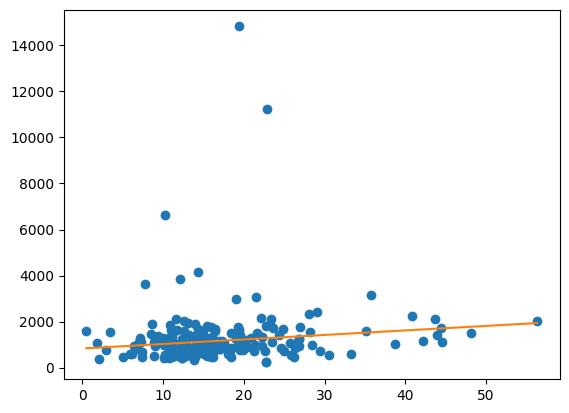

In [ ]:
beta=mco1.params
plt.plot(datos['roe'], y, 'o')
xmin=np.min(datos['roe'])
xmax=np.max(datos['roe'])
plt.plot([xmin,xmax], [beta[0]+beta[1]*xmin,beta[0]+beta[1]*xmax])
plt.show()

El modelo obtenido permite realizar algunas gráficas más que nos permitirán validar el modelo:

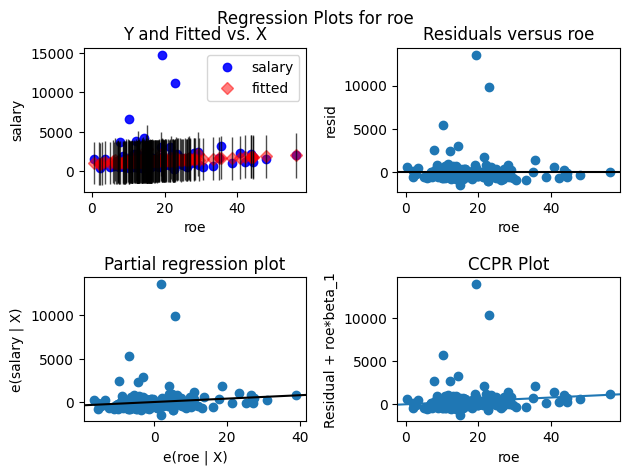

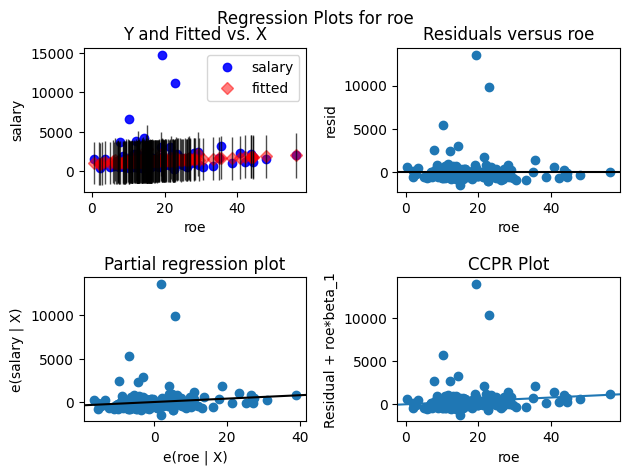

In [ ]:
sm.graphics.plot_regress_exog(mco1, 'roe')

Del modelo se pueden extraer otras medidas como:

* Valores predichos $\hat y$
* Residuos



In [ ]:
#yhat=mco1.fittedvalues
e=mco1.resid
print(e)
np.mean(e)

0     -463.373461
1     -206.338158
2     -270.065855
3     -633.939088
4      -89.510244
          ...    
204   -101.971074
205   -627.839644
206   -484.399224
207   -577.634553
208   -510.889949
Length: 209, dtype: float64


9.538815245388797e-12

* ANOVA

In [ ]:
table = sm.stats.anova_lm(mco1)
print(table)

             df        sum_sq       mean_sq         F    PR(>F)
roe         1.0  5.166419e+06  5.166419e+06  2.798493  0.095871
sales       1.0  6.261093e+06  6.261093e+06  3.391445  0.066973
Residual  206.0  3.803055e+08  1.846143e+06       NaN       NaN


* Suma de Cuadrados Totales (SCT)

In [ ]:
mco1.centered_tss


391732982.00956935

* Suma de Cuadrados Explicada (SCE)

In [ ]:
mco1.ess

11427511.78486675

* Suma de Cuadrados de los residuos (SCR)

In [ ]:
mco1.ssr

380305470.2247026

* $R^2$ y $R^2$-ajustado

In [ ]:
print("R2: ", mco1.rsquared)
print("R2 Ajustado: ", mco1.rsquared_adj)

R2:  0.029171686607148084
R2 Ajustado:  0.019746169001392255


* Valor $F_{exp}$ y de $F_{teo}$

In [ ]:
Fexp=mco1.fvalue
Fexp
from scipy import stats
alpha=0.025
Fteo= stats.f.ppf(1-alpha, mco1.df_model, mco1.df_resid)
Fteo
# print(alpha, Fexp, Fteo)
# alpha=0.10
# Fteo= stats.f.ppf(1-alpha, mco1.df_model, mco1.df_resid)
# print(alpha, Fexp, Fteo)

3.7557326025591484

In [ ]:
print(mco1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     3.095
Date:                Mon, 23 Oct 2023   Prob (F-statistic):             0.0474
Time:                        10:26:12   Log-Likelihood:                -1802.8
No. Observations:                 209   AIC:                             3612.
Df Residuals:                     206   BIC:                             3622.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    830.6313    223.905      3.710      0.0

* Valores $t_{exp}$ y $t_{teo}$

In [ ]:
texp=mco1.tvalues
print("texp: ", texp)
alpha=0.098
tteo= stats.t.ppf(1-(alpha/2),mco1.df_resid)
print(tteo)
# print(alpha)
# print(tteo)
# alpha=0.10
# tteo= stats.t.ppf(1-(alpha/2),mco1.df_resid)
# print(alpha)
# print(tteo)

texp:  Intercept    3.709751
roe          1.772300
sales        1.841588
dtype: float64
1.6621679027786715


* Intervalos de confianza de Estimadores

In [ ]:
mco1.conf_int(0.075)

,0,1
Intercept,429.948919,1231.313683
roe,-0.190747,39.452684
sales,0.000462,0.032221


* Estimación de la varianza de la pertrubación:

In [ ]:
beta=np.array(mco1.params)
e =mco1.resid
sum(e**2)/(mco1.nobs-1)
sigmagorro=(np.dot(y.values, y.values)-np.dot(beta.T, np.dot(X.values.T,y.values)))/(mco1.nobs-1)

sigmagorro



1828391.6837726156

* Predicciones:

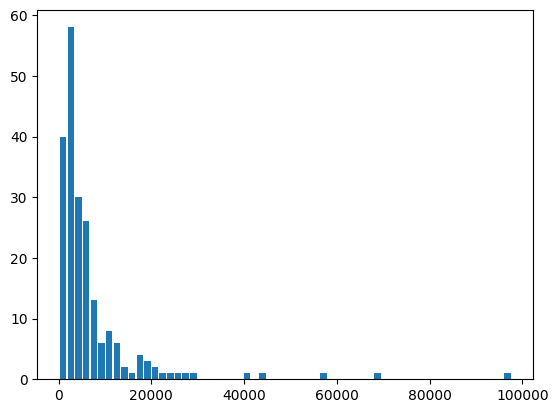

In [ ]:
histograma=plt.hist(datos["sales"], bins='auto', rwidth=0.85)

In [ ]:
x0=[5.5, 10000]
X0=sm.add_constant(x0)

mco1.predict(X0)

In [ ]:
predictions = mco1.get_prediction(X0)
predictions.summary_frame(alpha=0.05)

## Cuestiones

1. Analizar el salario en función de los años de educación utilizando la base de datos **wage1**. Interpretar los coeficientes obtenidos. Dibuja ajustes y residuos.
3. Ajustar el modelo lineal del porcentaje de votos obtenido por el candidato A en base al porcentaje de gastos de campa\~na para tal candidato con la base de datos **vote1**. Comprobar que la media de los residuos es 0 y cómo se relaciona la media de $y$ con respecto a la media de $\hat{y}$.
4. Ajustar el modelo no lineal $\log(wage) = \beta _0 + \beta_1 {\rm educ} + u$ con la base de datos {\bf wage1} e interpretar los resultados obtenidos.
5. Usar la base de datos {\bf 401K} para estudiar la relación entre el porcentage de trabajadores activos que est\'an inscritos en el plan de pensiones (prate) y la tase de contribución al plan (mrate)- cantidad promedio con que la empresa contribuye al plan de cada trabajador  por cada dolar que aporta el trabajador. Seg\'un este modelo, ¿qué prate se predice para mrate=3.5? ? Cu\'anta variación de prate se explica por mrate?
6. Usando la base de datos **charity**:
 * ¿Cuál es el donativo (gift) promedio de esta muestra? ¿Qu\'e porcentage no dio donativo?
 * ¿Cuál es el promedio de envíos por año (mailsyear)?
 * Estimar ${\rm gift} = \beta_0 + \beta_1 {\rm mailsyear} + u$.
 * Si cada envío cuesta un florín, espera la beneficiencia obtener una ganancia neta por cada env\'io?
 * ¿Cu\'al es el menor donativo? Con el modelo de regresi'on, se puede predecir que gift=0?
7. Realiza el siguiente experimento:
 * Generar $500$ observaciones uniformes $[0,10]$. Calcular para esta muestra la media y la desviación t\'ipica: $x$
 * Generar $500$ errores seg\'un una normal $N(0,36)$: $e$. ? Es el promedio de la muestra 0? ¿Cu\'al es su desviación t\'ipica?
 * Ahora generar $y_i = 1 + 2x_i + e_i$ para $i=1, \ldots, 500$.
 * Estimar el modelo $y = \beta_0 + \beta_1 x + u$. Comparar el modelo real con el modelo ajustado.
 * Obtener $\hat{u}$ y probar si $\sum_{i=1}^{500} \hat{u}_i =0$ y que $\sum_{i=1}^{500} x_i \hat{u}_i =0$. ¿Ocurre lo mismo con $u$?
 * Generar de nuevo el modelo y comparar los resultados obtenidos. ¿Son iguales?

zdfjngkjzñjlñxjflñsdjglñsj